# <font color="brown">Banking Product Clustering Case Study </font>

## <font color = "brown">Problem Statement </font>

### <font color="blue"> Context

A bank's product catalog has grown organically over many years, checking accounts, savings products, credit cards, loans, mortgages, CDs, and investment products, each added, priced, and managed somewhat independently by different product teams. Nobody has recently stepped back to ask: which of these products are actually *functionally similar*, serving similar customers with similar economics, regardless of which administrative category they happen to sit in?

The Head of Product Strategy has asked the analytics team to find natural groupings across the full product catalog, so the bank can identify consolidation opportunities, cross-sell bundles, and pricing inconsistencies that the existing category labels don't reveal.

### <font color="blue"> Objective

- How many meaningfully different groups of products are there, based on their economics and customer profile, not their administrative category?
- Do these groups match the bank's existing product categories, or cut across them?
- Which linkage method gives the most trustworthy, useful grouping for this data, and why?

### <font color="blue"> Data Dictionary

- **Product_ID**: Unique product identifier
- **Product_Name**: Name of the banking product
- **Category**: The bank's own existing category label (Checking, Savings, Credit Card, Personal Loan, Auto Loan, Mortgage, CD, Investment, Insurance), kept aside as a reference, not used in clustering
- **Interest_Rate**: % earned (deposit products) or charged (loans/cards)
- **Annual_Fee**: Yearly cost to hold the product
- **Min_Balance_Required**: Minimum balance needed to open/maintain the product
- **Avg_Customer_Age**: Average age of customers holding this product
- **Avg_Customer_Income**: Average income of customers holding this product
- **Revenue_Per_Customer_Annual**: Average annual revenue the bank earns per customer on this product
- **Customer_Count**: Number of customers currently holding this product
- **Risk_Score**: Credit/default or volatility risk, 1 (lowest) to 10 (highest)
- **Avg_Tenure_Years**: Average number of years customers keep this product

## <font color="brown"> Importing Necessary Libraries

In [3]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to perform hierarchical clustering and compute distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist

# to compute the silhouette score
from sklearn.metrics import silhouette_score

%matplotlib inline

## <font color="brown"> Reading the Dataset

In [5]:
# loading the dataset
data = pd.read_csv("banking_products.csv")

## <font color="brown"> Overview of the Dataset

### <font color="blue"> Checking the Shape of the Dataset

In [8]:
data.shape

(41, 12)

* The dataset has 41 rows and 12 columns, one row per banking product.

### <font color="blue"> Displaying a Few Rows of the Dataset

In [11]:
data.sample(n=10, random_state=1)

,Product_ID,Product_Name,Category,Interest_Rate,Annual_Fee,Min_Balance_Required,Avg_Customer_Age,Avg_Customer_Income,Revenue_Per_Customer_Annual,Customer_Count,Risk_Score,Avg_Tenure_Years
3,P004,Senior Checking,Checking,0.10,0,500,68,52000,90,11000,1,9.0
2,P003,Premium Checking,Checking,0.15,12,2500,46,110000,220,8500,1,7.5
23,P024,15-Year Fixed Mortgage,Mortgage,5.80,350,0,44,128000,1450,4200,3,13.0
38,P039,529 College Savings,Investment,5.50,0,250,38,92000,90,3200,3,10.0
17,P018,Personal Loan - Secured,Personal Loan,9.50,0,0,41,62000,260,1900,5,3.0
28,P029,HELOC,Mortgage,8.50,75,0,48,118000,620,2900,3,8.5
19,P020,New Auto Loan,Auto Loan,6.00,0,0,36,68000,280,5200,4,5.0
34,P035,IRA CD,CD,4.40,0,1000,57,82000,95,2200,1,4.0
30,P031,CD 6-Month,CD,4.10,0,500,56,63000,45,2800,1,0.5
22,P023,30-Year Fixed Mortgage,Mortgage,6.50,350,0,40,105000,1600,9800,3,22.0


### <font color="blue"> Creating a Copy of the Original Data

In [13]:
# copying the data to another variable to avoid any changes to the original data
df = data.copy()

### <font color="blue"> Checking the Data Types of the Columns

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Product_ID                   41 non-null     object 
 1   Product_Name                 41 non-null     object 
 2   Category                     41 non-null     object 
 3   Interest_Rate                41 non-null     float64
 4   Annual_Fee                   41 non-null     int64  
 5   Min_Balance_Required         41 non-null     int64  
 6   Avg_Customer_Age             41 non-null     int64  
 7   Avg_Customer_Income          41 non-null     int64  
 8   Revenue_Per_Customer_Annual  41 non-null     int64  
 9   Customer_Count               41 non-null     int64  
 10  Risk_Score                   41 non-null     int64  
 11  Avg_Tenure_Years             41 non-null     float64
dtypes: float64(2), int64(7), object(3)
memory usage: 4.0+ KB


**Observations**

- `Product_ID` and `Product_Name` are identifiers, and `Category` is the bank's own existing label, none of the three carry the kind of behavioral/economic information clustering needs, so all three will be set aside before clustering (`Category` will still be useful afterward, to check what the clusters found against what the bank already labels).
- Every remaining column is numeric, which is what hierarchical clustering needs, like K-Means, it works on distance between points, so it can only operate on numbers.

### <font color="blue"> Statistical Summary of the Dataset

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Interest_Rate,41.0,7.628049,7.232548,0.00,3.8,6.0,8.5,24.5
Annual_Fee,41.0,75.292683,147.846245,0.00,0.0,0.0,75.0,550.0
Min_Balance_Required,41.0,327.439024,624.494918,0.00,0.0,0.0,500.0,2500.0
Avg_Customer_Age,41.0,41.463415,11.169372,12.00,36.0,40.0,46.0,68.0
Avg_Customer_Income,41.0,76975.609756,43189.980207,0.00,52000.0,68000.0,95000.0,260000.0
Revenue_Per_Customer_Annual,41.0,399.512195,542.249717,10.00,90.0,220.0,380.0,2600.0
Customer_Count,41.0,7531.707317,8622.686328,1400.00,2800.0,4600.0,8500.0,42000.0
Risk_Score,41.0,3.219512,2.006392,1.00,1.0,3.0,5.0,7.0
Avg_Tenure_Years,41.0,5.908537,4.875242,0.25,3.0,4.0,8.0,22.0


**Observations**

- The features are on very different scales, `Avg_Customer_Income` runs into the hundreds of thousands while `Risk_Score` is bounded 1-10 and `Interest_Rate` rarely exceeds 25. As with K-Means, we will need to scale everything before computing any distances.
- `Customer_Count` and `Revenue_Per_Customer_Annual` both have wide ranges, a handful of very popular or very high-revenue products alongside many niche ones.

### <font color="blue"> Checking for Missing Values and Duplicates

In [21]:
df.isna().sum()

Product_ID                     0
Product_Name                   0
Category                       0
Interest_Rate                  0
Annual_Fee                     0
Min_Balance_Required           0
Avg_Customer_Age               0
Avg_Customer_Income            0
Revenue_Per_Customer_Annual    0
Customer_Count                 0
Risk_Score                     0
Avg_Tenure_Years               0
dtype: int64

In [22]:
df.duplicated().sum()

0

- There are no missing values and no duplicate rows.

## <font color="brown"> Exploratory Data Analysis

### <font color="blue"> Product Categories

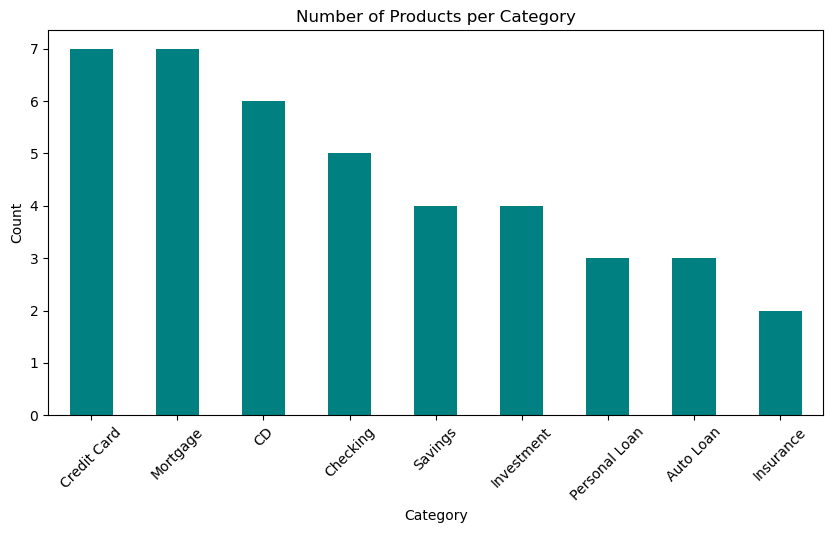

In [26]:
plt.figure(figsize=(10, 5))
df['Category'].value_counts().plot(kind='bar', color='teal')
plt.title('Number of Products per Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Observations**

- Credit Cards and Mortgages have the most product variants (7 each), Insurance has the fewest (2). This is exactly the kind of catalog sprawl that motivates the analysis, some categories may be over-segmented with near-duplicate products.

### <font color="blue"> Univariate Analysis

In [29]:
# function to plot a boxplot and a histogram along the same scale
def histogram_boxplot(data, feature, figsize=(12, 6), bins="auto"):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist2, bins=bins, color="skyblue")
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")
    plt.suptitle(feature)
    plt.show()

In [30]:
num_col = [c for c in df.columns if c not in ("Product_ID", "Product_Name", "Category")]
num_col

['Interest_Rate',
 'Annual_Fee',
 'Min_Balance_Required',
 'Avg_Customer_Age',
 'Avg_Customer_Income',
 'Revenue_Per_Customer_Annual',
 'Customer_Count',
 'Risk_Score',
 'Avg_Tenure_Years']

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


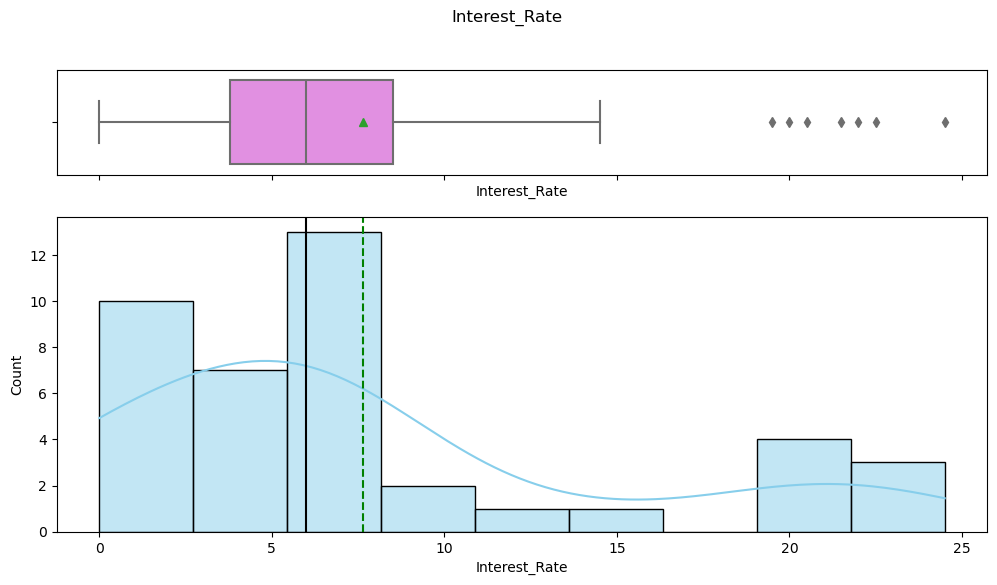

In [31]:
histogram_boxplot(df, "Interest_Rate")

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


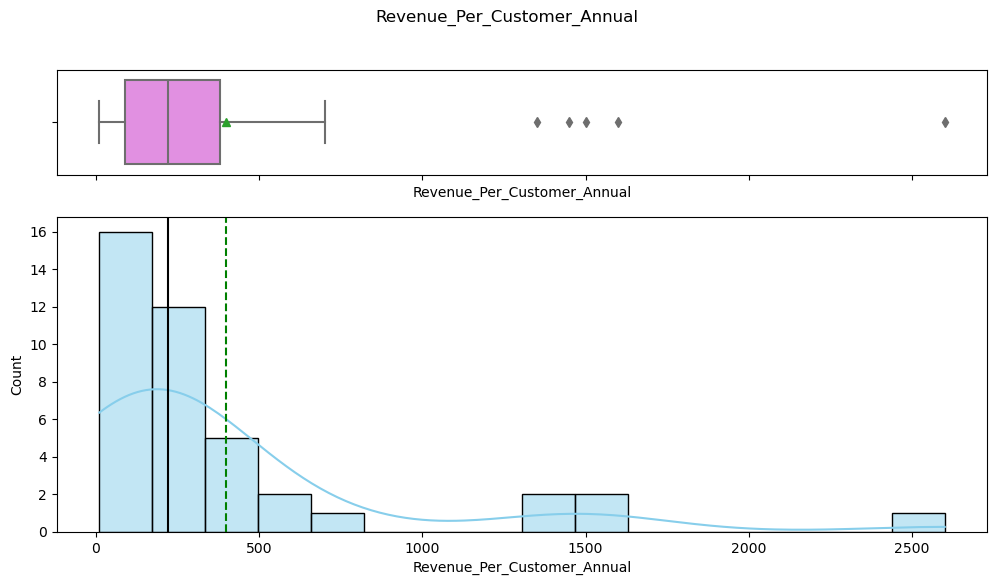

In [32]:
histogram_boxplot(df, "Revenue_Per_Customer_Annual")

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


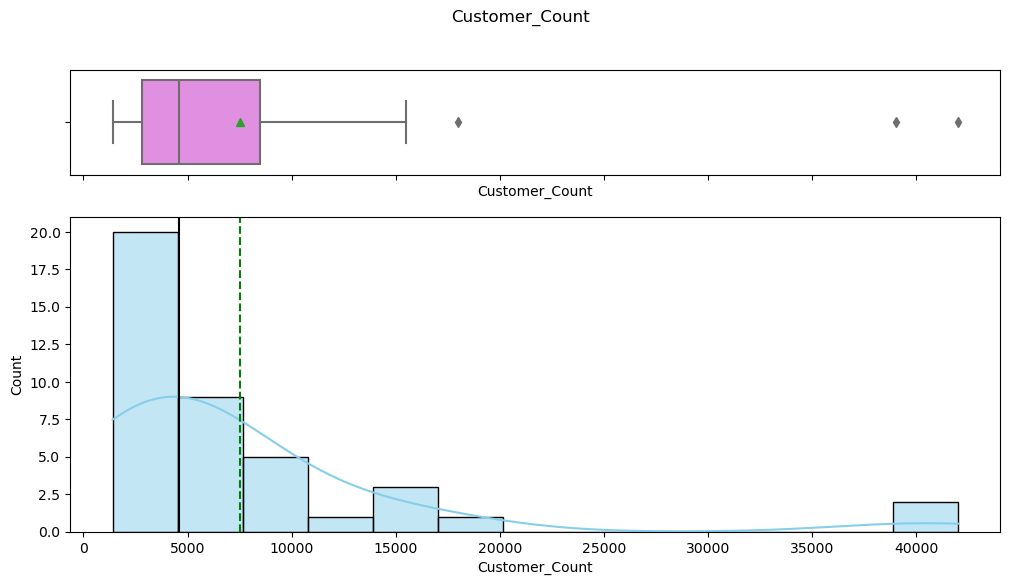

In [33]:
histogram_boxplot(df, "Customer_Count")

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


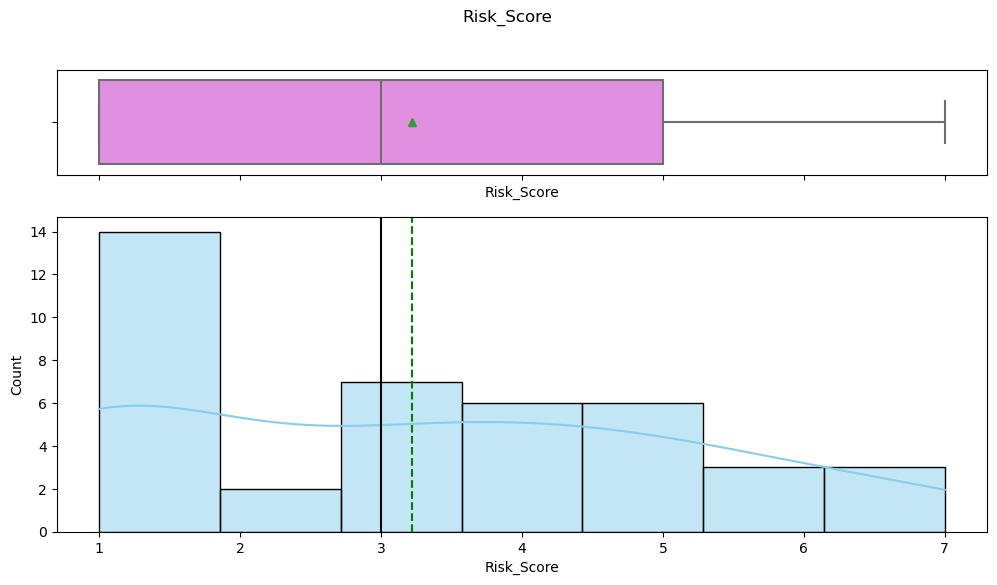

In [34]:
histogram_boxplot(df, "Risk_Score", bins=7)

**Observations**

- `Interest_Rate` is bimodal, low rates for deposit products, high rates for credit cards, with lending products spread in between.
- `Revenue_Per_Customer_Annual` and `Customer_Count` are both right-skewed, a few high-revenue or high-volume products, a longer tail of niche ones.
- `Risk_Score` clusters at the low end (deposit products) with a smaller group at the high end (credit cards, unsecured lending).

### <font color="blue"> Correlation Between Features

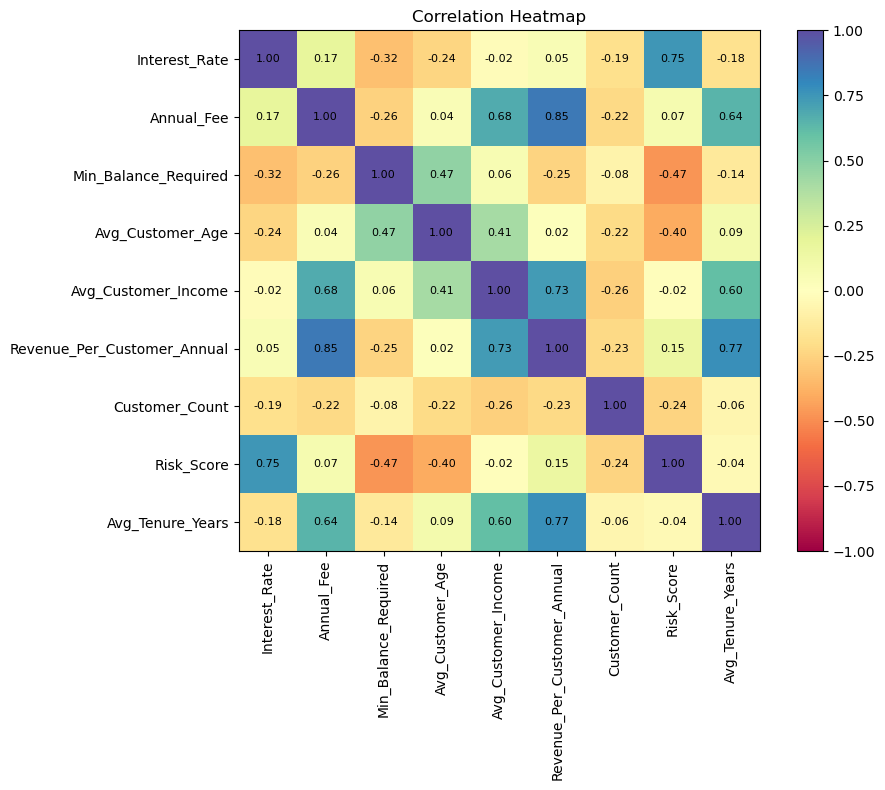

In [37]:
corr_matrix = df[num_col].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='Spectral', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observations**

- `Avg_Tenure_Years` correlates strongly with `Annual_Fee` and `Revenue_Per_Customer_Annual`, products customers keep the longest (mortgages, retirement accounts) also tend to be the ones that earn the bank the most per customer.
- `Risk_Score` correlates positively with `Interest_Rate`, higher-risk products charge more, exactly what we'd expect from risk-based pricing.
- `Customer_Count` is only weakly correlated with everything else, popularity is close to an independent dimension from a product's economics.

## <font color="brown"> Data Preprocessing

Hierarchical clustering, like K-Means, measures how far apart products are using distance (most commonly Euclidean), so before clustering we set aside the identifier/label columns and scale every remaining feature so `Avg_Customer_Income` doesn't dominate the distance calculation just because of its units.

In [41]:
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)
subset_scaled_df.head()

,Interest_Rate,Annual_Fee,Min_Balance_Required,Avg_Customer_Age,Avg_Customer_Income,Revenue_Per_Customer_Annual,Customer_Count,Risk_Score,Avg_Tenure_Years
0,-1.060786,-0.515590,-0.530840,-0.676505,-0.749545,-0.633896,4.047055,-1.119963,-0.292505
1,-1.060786,-0.515590,-0.530840,-1.945503,-1.523103,-0.699244,0.231105,-1.119963,-0.811671
2,-1.046788,-0.433416,3.522127,0.411209,0.774130,-0.335163,0.113691,-1.119963,0.330493
3,-1.053787,-0.515590,0.279754,2.405350,-0.585457,-0.577884,0.407226,-1.119963,0.641992
4,-1.053787,-0.412873,1.900940,0.139280,0.422512,-0.111114,-0.156361,-0.615364,0.018994


## <font color="brown"> Hierarchical Clustering

Unlike K-Means, hierarchical clustering doesn't require choosing the number of clusters upfront. Instead, it builds a **dendrogram**, a tree that starts with every product as its own cluster and repeatedly merges the two closest clusters until everything is in one cluster. Cutting that tree at any height gives you a specific number of clusters, after the fact.

The one choice hierarchical clustering *does* require upfront is **linkage**: the rule for measuring "distance between two clusters" once a cluster has more than one point in it. This choice matters a lot, and it's a decision K-Means never has to make.

### <font color="blue"> Linkage Methods

* **Single**: distance between the *closest* pair of points across two clusters. Cheap to compute, but prone to **chaining**, a few close-together points can string two otherwise very different clusters into one long, straggly chain.
* **Complete**: distance between the *farthest* pair of points across two clusters. Tends to produce tight, compact, evenly-sized clusters, the opposite failure mode of single linkage.
* **Average**: the average distance across *every* pair of points between the two clusters. A middle ground between single and complete.
* **Weighted**: like average, but each earlier sub-cluster contributes equally to the average regardless of how many points it has, so a large sub-cluster can't dominate.
* **Centroid**: distance between the two clusters' centroids (mean points). 
* **Median**: like centroid, but weights sub-clusters equally rather than by size. Same inversion risk as centroid.
* **Ward**: merges whichever pair of clusters increases the total within-cluster variance the least. Usually the best default for roughly round, evenly-sized clusters in Euclidean space, and the most commonly used in practice.

Centroid, median, and Ward all specifically require Euclidean distance; single, complete, average, and weighted can work with any distance metric.

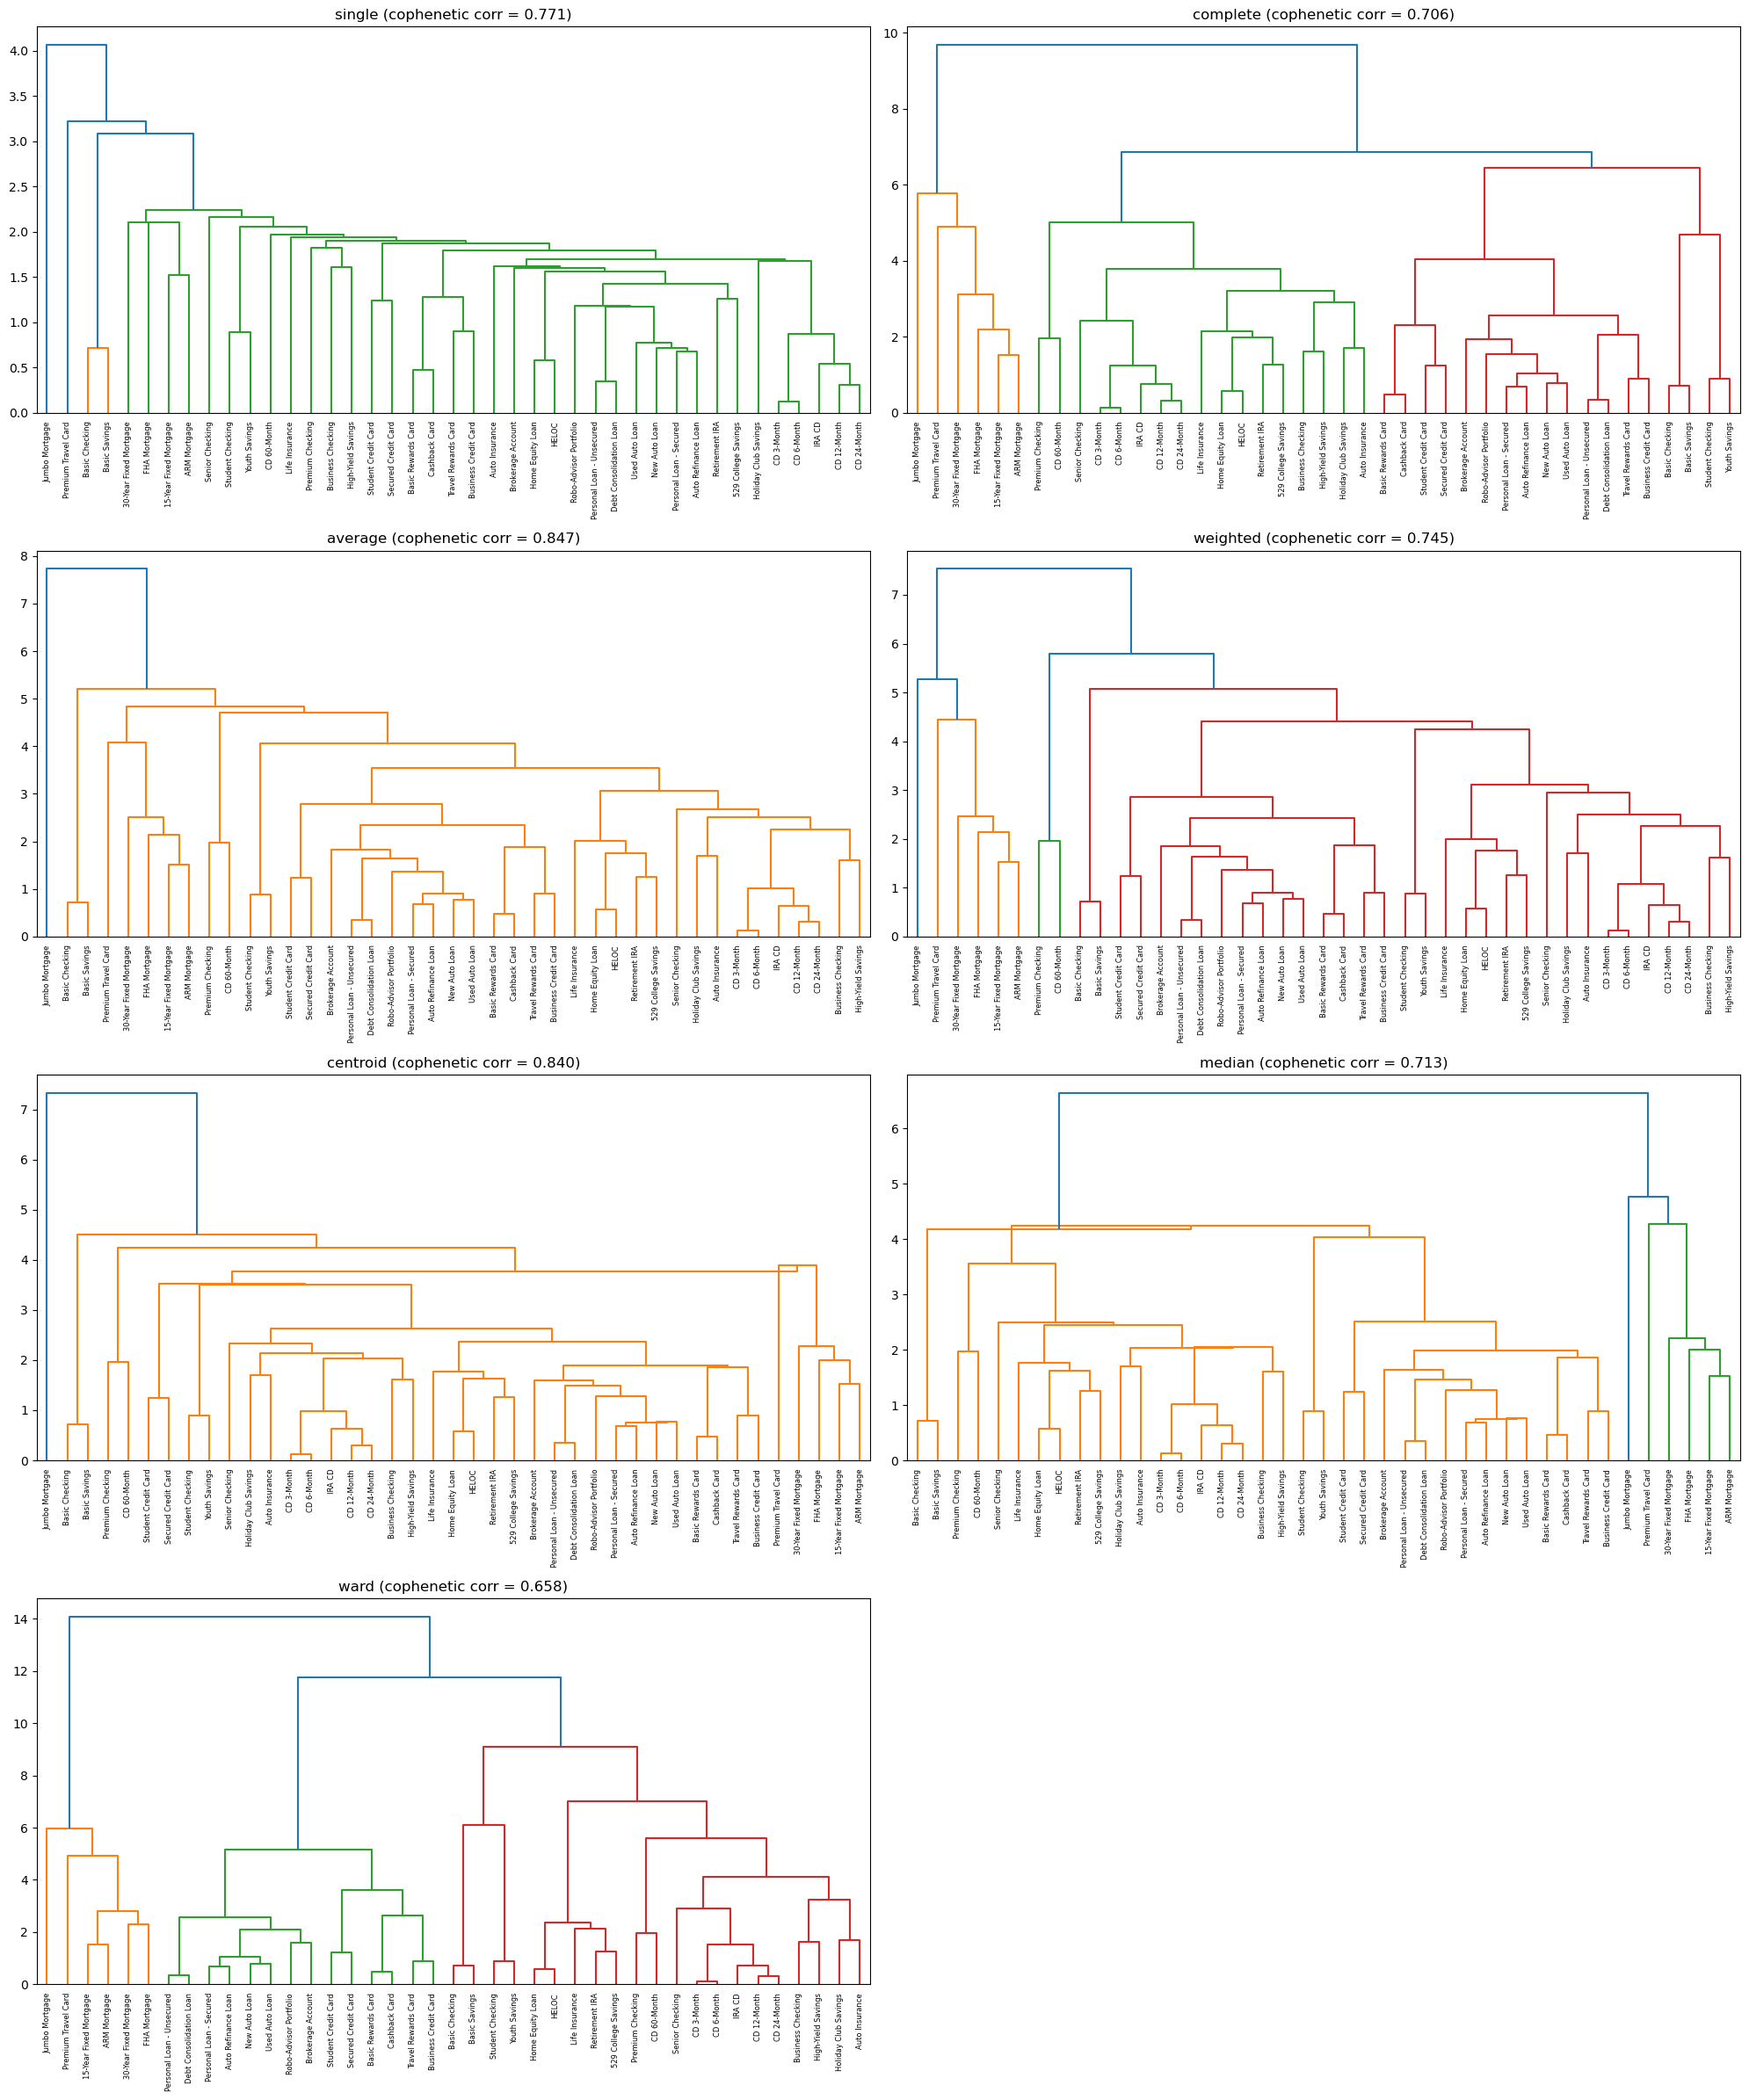

In [45]:
linkage_methods = ['single', 'complete', 'average', 'weighted', 'centroid', 'median', 'ward']

fig, axes = plt.subplots(4, 2, figsize=(20, 24))
axes = axes.ravel()

linkage_matrices = {}
cophenetic_scores = {}

for ax, method in zip(axes, linkage_methods):
    Z = linkage(subset_scaled_df, method=method)
    linkage_matrices[method] = Z
    coph_corr, _ = cophenet(Z, pdist(subset_scaled_df))
    cophenetic_scores[method] = coph_corr
    dendrogram(Z, labels=df['Product_Name'].values, ax=ax, leaf_rotation=90, leaf_font_size=6)
    ax.set_title(f'{method} (cophenetic corr = {coph_corr:.3f})')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

**The cophenetic correlation coefficient** measures how faithfully a dendrogram preserves the *actual* pairwise distances between products, closer to 1 means the tree structure is a more trustworthy summary of the real distances.

In [47]:
pd.Series(cophenetic_scores, name='Cophenetic Correlation').sort_values(ascending=False)

average     0.847157
centroid    0.839901
single      0.770865
weighted    0.745006
median      0.712738
complete    0.706378
ward        0.657683
Name: Cophenetic Correlation, dtype: float64

**Observations**

- **Single linkage's chaining problem is visible right in the dendrogram**: `Jumbo Mortgage` and `Premium Travel Card` split off almost immediately as near-isolated points, and nearly every other product then merges into one long chain at very low heights. This is exactly the failure mode single linkage is known for, it isn't finding meaningful groups, it's just repeatedly attaching whichever single point happens to be nearest.
- **Average has the highest cophenetic correlation** (≈0.85), its tree structure best preserves the real distances between products, closely followed by **centroid** (≈0.84).
- **Ward has the lowest cophenetic correlation** (≈0.66) of the seven, but that's expected, not a flaw: Ward isn't trying to preserve raw distances, it's minimizing within-cluster variance, a different objective entirely. Judging Ward by cophenetic correlation is judging it against a goal it was never optimizing for.

### <font color="blue"> Selecting the Final Linkage Method

**We'll use Ward linkage for the final clustering:**

- It's the only method (besides average) with zero inversions, so the dendrogram can be trusted and read at face value.
- It produces clean, balanced splits, visibly more so than single (chained) or complete (a few very unbalanced branches).
- Its lower cophenetic correlation isn't a weakness here, it reflects a genuinely different, and for building *usable business segments*, more appropriate objective (compact, low-variance groups) than raw distance preservation.
- It's the standard default for this kind of numeric, Euclidean business data.

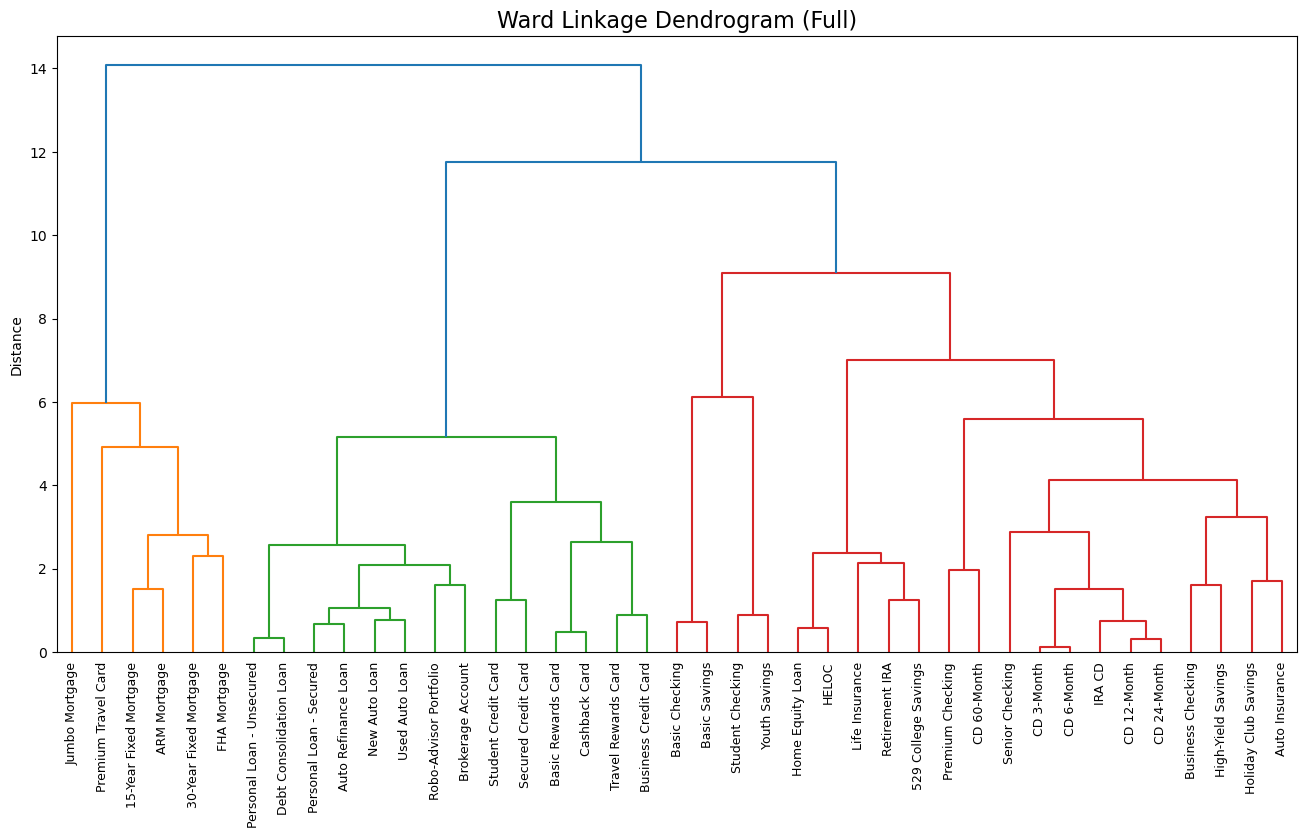

In [51]:
plt.figure(figsize=(16, 8))
dendrogram(linkage_matrices['ward'], labels=df['Product_Name'].values, leaf_rotation=90, leaf_font_size=9)
plt.title('Ward Linkage Dendrogram (Full)', fontsize=16)
plt.ylabel('Distance')
plt.show()

### <font color="blue"> Choosing the Number of Clusters

k=2: silhouette=0.3543
k=3: silhouette=0.2623
k=4: silhouette=0.3103
k=5: silhouette=0.2641
k=6: silhouette=0.3082
k=7: silhouette=0.3155
k=8: silhouette=0.3311
k=9: silhouette=0.3241


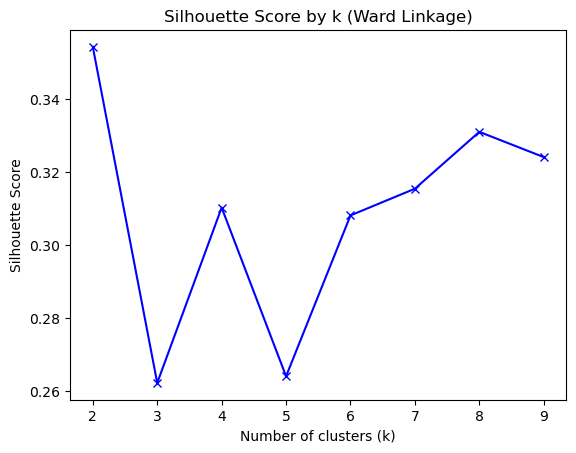

In [53]:
sil_scores = {}
for k in range(2, 10):
    labels = fcluster(linkage_matrices['ward'], k, criterion='maxclust')
    sil_scores[k] = silhouette_score(subset_scaled_df, labels)
    print(f"k={k}: silhouette={sil_scores[k]:.4f}")

plt.plot(list(sil_scores.keys()), list(sil_scores.values()), 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k (Ward Linkage)')
plt.show()

**k=4 gives a clear local peak in silhouette score, a meaningfully better split than k=3 or k=5 on either side, and produces 4 groups of a practical size for building business strategy around (rather than 8-9 tiny fragments). We'll cut the dendrogram at k=4.**

In [55]:
df['Cluster'] = fcluster(linkage_matrices['ward'], 4, criterion='maxclust')
df['Cluster'].value_counts().sort_index()

Cluster
1     6
2    14
3     4
4    17
Name: count, dtype: int64

## <font color="brown"> Cluster Profiling

In [57]:
cluster_profile = df.groupby('Cluster')[num_col].mean()
cluster_profile['count_in_cluster'] = df.groupby('Cluster')['Product_ID'].count().values
cluster_profile.style.highlight_max(color='lightgreen', axis=0)

,Interest_Rate,Annual_Fee,Min_Balance_Required,Avg_Customer_Age,Avg_Customer_Income,Revenue_Per_Customer_Annual,Customer_Count,Risk_Score,Avg_Tenure_Years,count_in_cluster
Cluster,,,,,,,,,,
1,8.883333,400.000000,0.000000,40.833333,133000.000000,1520.000000,3950.000000,3.500000,13.583333,6
2,14.178571,18.214286,57.142857,35.928571,62071.428571,261.071429,6135.714286,5.500000,3.464286,14
3,0.362500,0.000000,81.250000,26.000000,26250.000000,35.000000,24425.000000,1.000000,3.750000,4
4,3.500000,25.411765,723.529412,49.882353,81411.764706,203.823529,5970.588235,1.764706,5.720588,17


Let's also check whether these clusters match the bank's own existing `Category` labels, or cut across them.

In [59]:
pd.crosstab(df['Cluster'], df['Category'])

Category,Auto Loan,CD,Checking,Credit Card,Insurance,Investment,Mortgage,Personal Loan,Savings
Cluster,,,,,,,,,
1,0,0,0,1,0,0,5,0,0
2,3,0,0,6,0,2,0,3,0
3,0,0,2,0,0,0,0,0,2
4,0,6,3,0,2,2,2,0,2


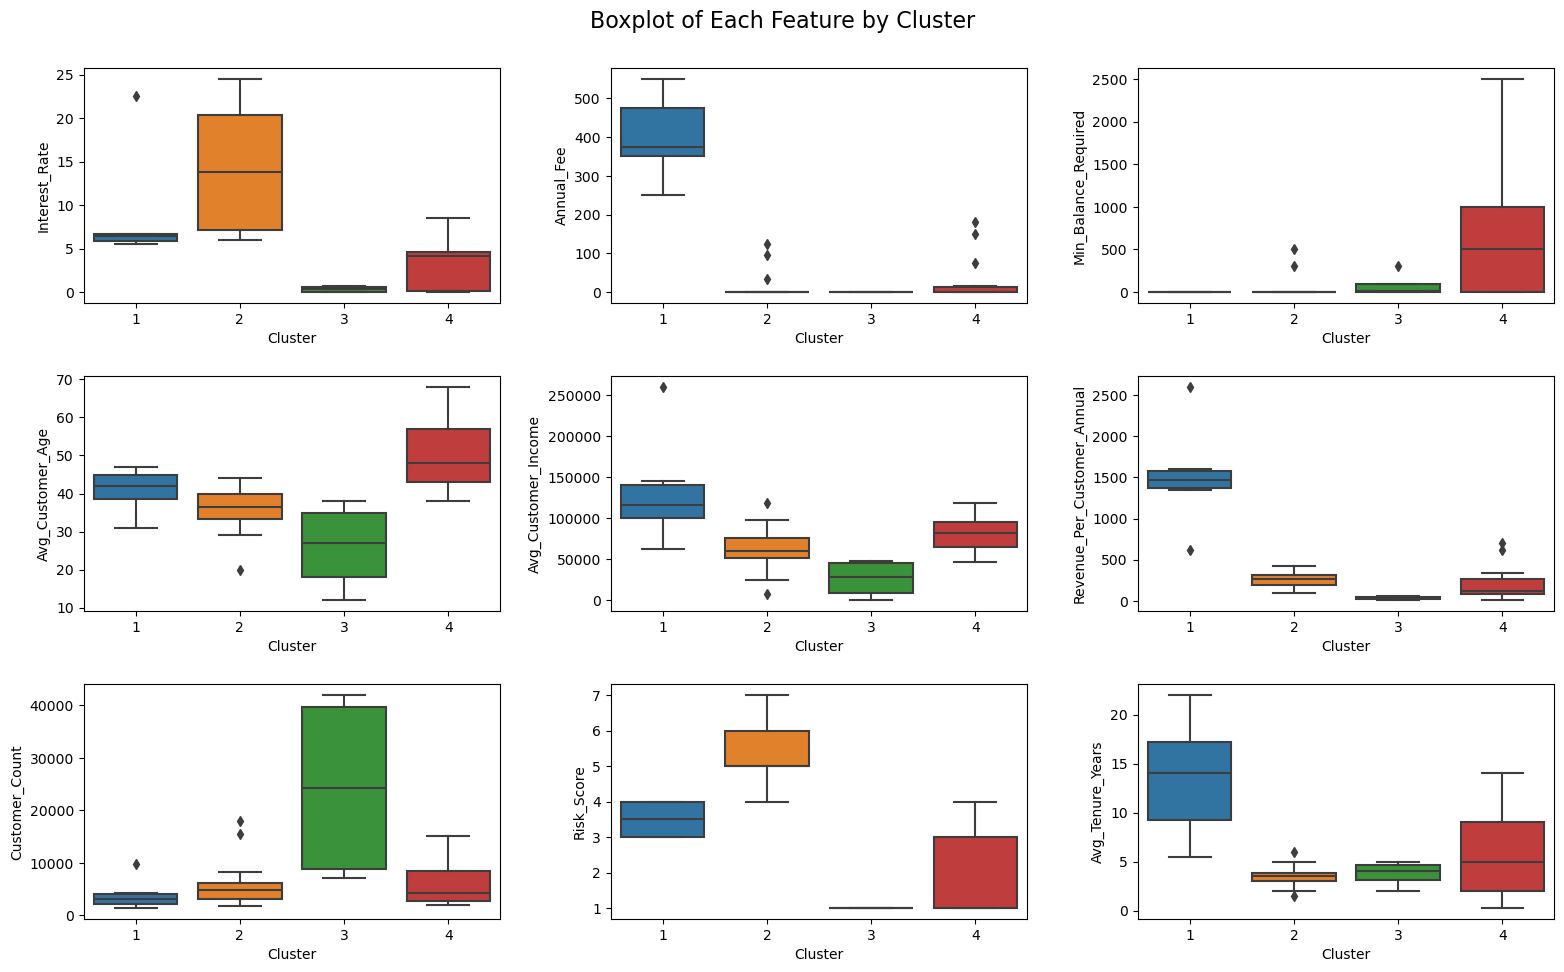

In [60]:
plt.figure(figsize=(16, 10))
plt.suptitle('Boxplot of Each Feature by Cluster', fontsize=16)

for i, variable in enumerate(num_col):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=df, x='Cluster', y=variable)

plt.tight_layout(pad=2.0)
plt.show()

### <font color="blue"> Insights

- **Cluster 1 — High-Value Long-Term Secured Lending (6 products):** Almost entirely mortgages, plus one notable outlier: `Premium Travel Card`. High revenue per customer, high annual fees, long average tenure. The travel card ends up here not because it's a loan, but because *economically* it behaves like one, high fee, high revenue, high-income cardholders, closer to a mortgage's profile than to a basic credit card's.

- **Cluster 2 — Everyday Credit & Higher-Risk Lending (14 products):** Every remaining credit card, all personal and auto loans, and 2 investment products. The highest average `Risk_Score` and `Interest_Rate` of the four clusters, shorter tenure, this is the bank's revolving/short-to-medium-term credit business.

- **Cluster 3 — Entry-Level Deposit Products (4 products):** `Basic Checking`, `Student Checking`, `Basic Savings`, `Youth Savings`. Lowest income, lowest revenue, lowest fees of any cluster, a clean, coherent "first product" group for younger or lower-balance customers.

- **Cluster 4 — Stable, Low-Risk Relationship Products (17 products):** The largest cluster, premium/senior/business checking, high-yield savings, home equity products, every CD, and the retirement/education/insurance products. Lowest risk scores, longest tenures alongside Cluster 1. These products cut across five different bank categories, but they all share the same underlying profile: low-risk, high-retention, relationship-oriented.

## <font color="brown"> Business Insights and Recommendations

- **The bank's category labels don't match its economics.** Cluster 4 alone spans Checking, Savings, Mortgage, CD, Investment, and Insurance products, all administratively different, but functionally the same kind of low-risk, long-tenure relationship product. A single "stable relationship customer" strategy, and a single team, could reasonably serve all of them instead of six separate ones.

- **`Premium Travel Card` is mispositioned as a "credit card."** It clusters with mortgages on revenue, fee, and customer profile. Consider managing and marketing it alongside the bank's premium/high-net-worth products rather than its mass-market card lineup.

- **Cluster 2's 14 products are a consolidation opportunity.** Six credit cards, three personal loans, and three auto loans all landed in one economically similar group. Before adding another product here, the bank should ask whether an existing one already serves that customer, this cluster is the most likely place the catalog has redundant, near-duplicate offerings.

- **Cluster 3 is a natural onboarding bundle.** All four entry-level deposit products cluster tightly together with low variance, a strong candidate for a single "starter bundle" marketed to students and new-to-banking customers, rather than four separate product pages and separate onboarding flows.

- **Cluster 1 (mortgages + the premium card) deserves the bank's best relationship management,** highest revenue per customer and longest tenure of any group, protecting and deepening these relationships likely matters more than acquiring new, lower-value customers elsewhere.

## <font color="brown"> Final Product-to-Cluster Mapping

In [66]:
product_clusters = df[['Product_ID', 'Product_Name', 'Category', 'Cluster']].sort_values('Cluster')
product_clusters

,Product_ID,Product_Name,Category,Cluster
26,P027,FHA Mortgage,Mortgage,1
25,P026,Jumbo Mortgage,Mortgage,1
24,P025,ARM Mortgage,Mortgage,1
23,P024,15-Year Fixed Mortgage,Mortgage,1
22,P023,30-Year Fixed Mortgage,Mortgage,1
12,P013,Premium Travel Card,Credit Card,1
20,P021,Used Auto Loan,Auto Loan,2
17,P018,Personal Loan - Secured,Personal Loan,2
16,P017,Personal Loan - Unsecured,Personal Loan,2
15,P016,Business Credit Card,Credit Card,2
